# Classificação


In [1]:
%%html
<link rel="stylesheet" href="./style.css">


'Data types:'

age                    int64
systolic_bp            int64
diastolic_bp           int64
blood_sugar          float64
body_temperature     float64
heart_rate             int64
risk_level          category
dtype: object

'\nMissing values:'

age                 0
systolic_bp         0
diastolic_bp        0
blood_sugar         0
body_temperature    0
heart_rate          0
risk_level          0
dtype: int64

'\nDuplicated rows:'

np.int64(9)

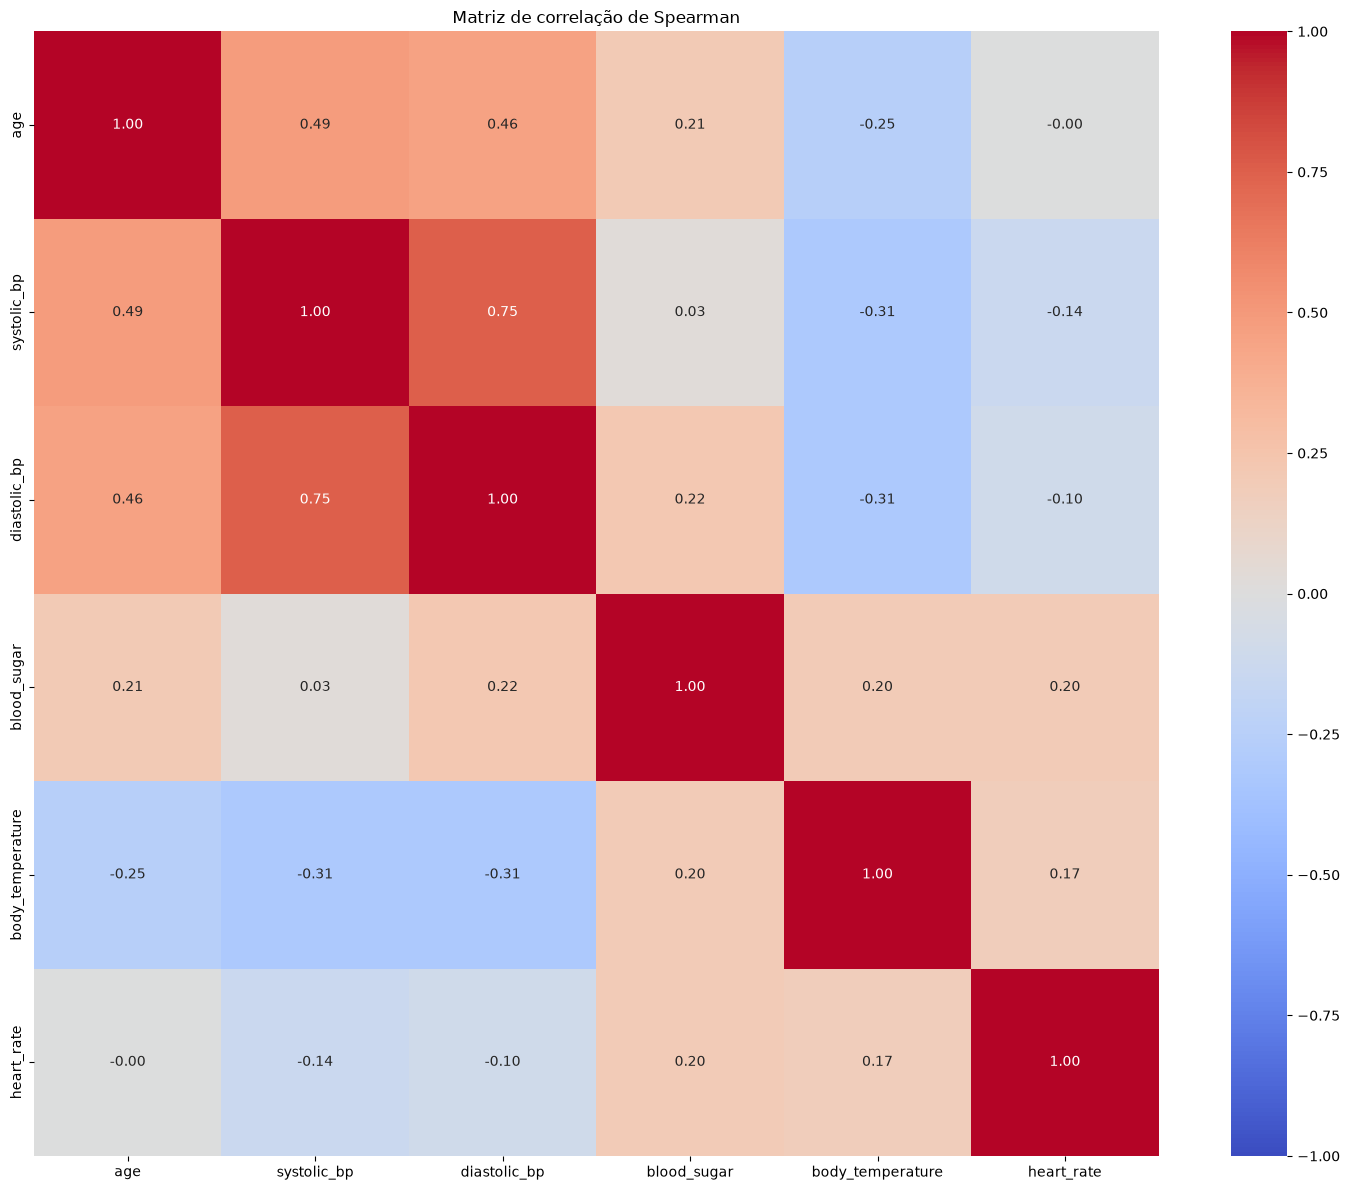

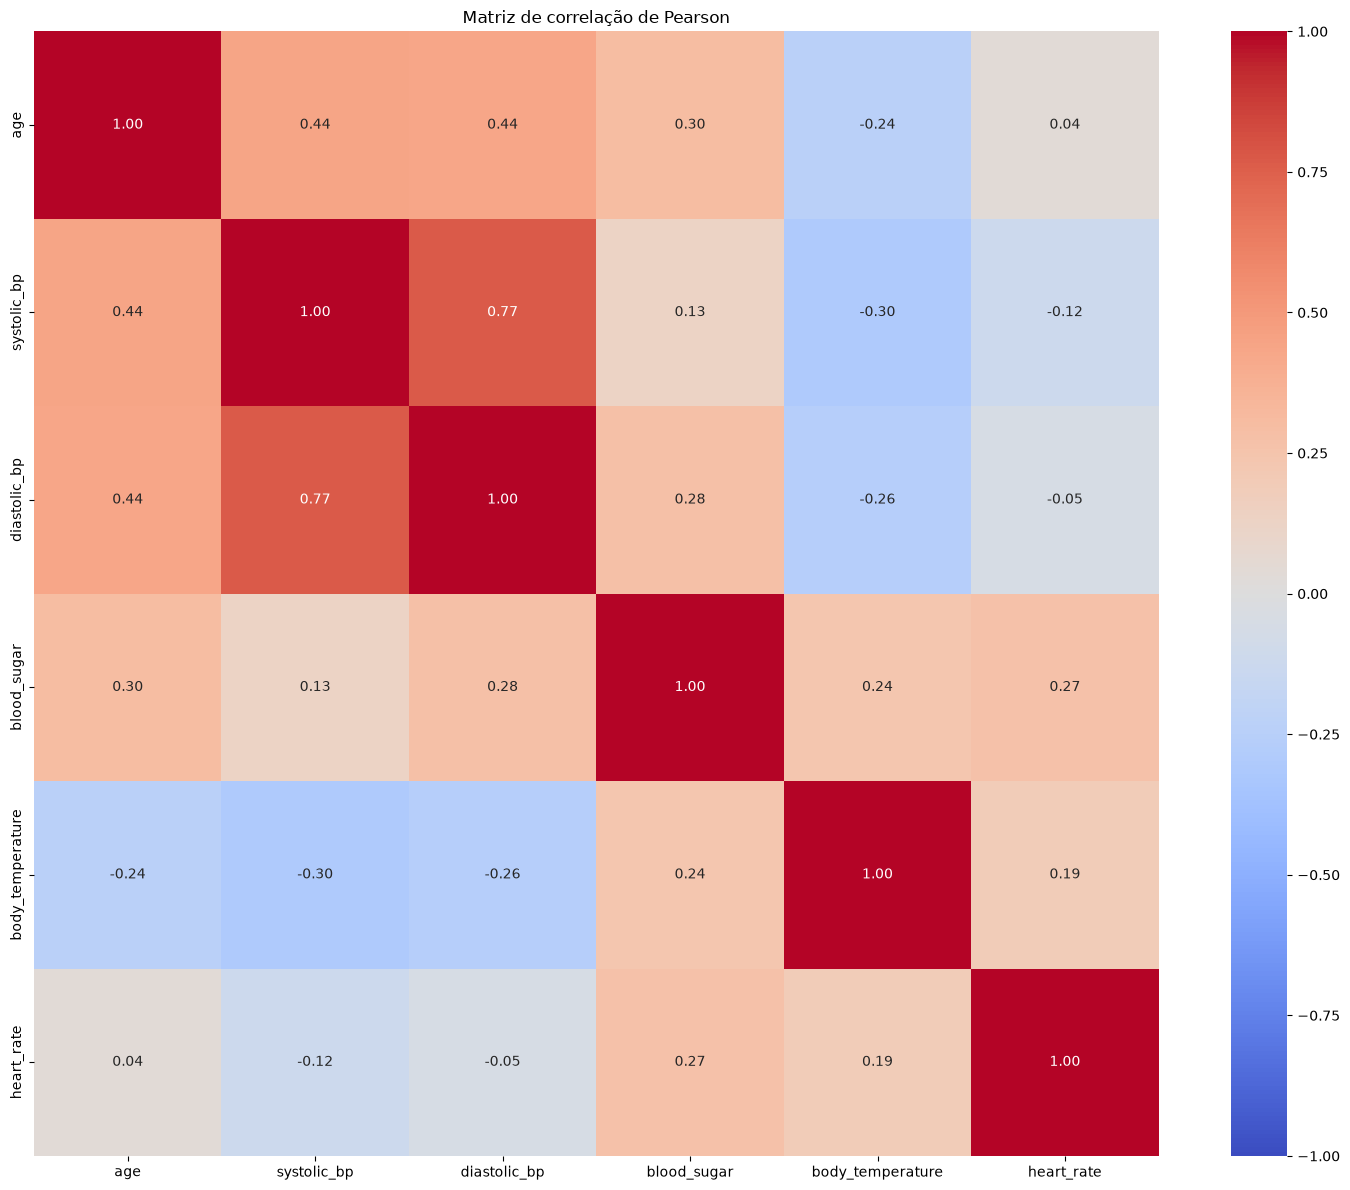

Variável 1,Variável 2,Correlação
systolic_bp,diastolic_bp,0.770


In [2]:
import import_ipynb  # noqa: F401
from treatment import (  # type: ignore
    t_df,
    t_numerical_columns,
)

In [3]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from categorical import levels_of_risk
from illustration import (
    best_parameters_table,
    calculate_classification_metrics,
    class_distribution_table,
    classification_metrics_comparison_table,
    feature_importance_table,
    fold_size_table,
    grid_search_results_table,
    plot_decision_tree,
    stratified_fold_table,
    train_test_split_table,
)

seed = 24

## Separação dos dados

Separamos os dados em **treino** (`80%`) e **teste** (`20%`) de forma estratificada pelo atributo objetivo:

- **Grau de risco**: `low`, `mid`, `high`.


In [4]:
input_data = t_df.drop(columns=["risk_level"])
output_data = t_df["risk_level"]

(
    input_data_for_train,
    input_data_for_test,
    output_data_for_train,
    output_data_for_test,
) = train_test_split(
    input_data,
    output_data,
    test_size=0.2,
    random_state=seed,
    stratify=output_data,
)

In [5]:
display(
    train_test_split_table(
        input_data_for_train,
        input_data_for_test,
    )
)

,dataset,samples,percentage,features
0,train,66,79.52%,5
1,test,17,20.48%,5


## Balanceamento


In [6]:
display(
    class_distribution_table(
        output_data_for_train, caption="Distribuição das classes para o treino"
    )
)

display(
    class_distribution_table(
        output_data_for_test, caption="Distribuição das classes para o teste"
    )
)


,count,percentage
Risk level,,
low,28,42.42%
mid,21,31.82%
high,17,25.76%


,count,percentage
Risk level,,
low,8,47.06%
mid,5,29.41%
high,4,23.53%


Dado que o desbalanceamento entre as classes não é acentuado, decidimos não fazer um balanceamento artificial por ora, e observar o desempenho das técnicas de ajuste de hiper-parâmetros.


## KNN

Usamos a padronização `StandardScaler` para viabilizar os cálculos de distâncias.


In [7]:
knn_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("classifier", KNeighborsClassifier()),
    ]
)

### Ajuste de hiper-parâmetros

Utilizamos o **GridSearch** para encontrarmos os melhores valores de hiper-parâmetros.

- Testamos os seguintes valores de **K**-vizinhos: [`3`, `5`, `7`, `9`, `11`].
- Testamos os seguintes métodos de cálculo de **pesos**: [`uniform`, `distance`].
- Testamos as seguintes métricas de **distância**: [`euclidean`, `manhattan`].

Como **critério de seleção**, utilizamos `f1_macro`.

- A métrica `F1` que combina _precision_ e _recall_ para cada classe objetivo.
- O `F1 macro` calcula a média dos valores de F1 das três.

Executamos o GridSearch em `5` **folds** estratificados no conjunto de `treino`.


In [8]:
stratified_fold_table(
    input_data_for_train,
    output_data_for_train,
)

,fold,validation_samples,high_samples,low_samples,mid_samples
0,1,14,4,6,4
1,2,13,3,6,4
2,3,13,3,6,4
3,4,13,3,5,5
4,5,13,4,5,4


In [9]:
fold_size_table(
    input_data_for_train,
    output_data_for_train,
)

,fold,training_samples,validation_samples,total_samples
0,1,52,14,66
1,2,53,13,66
2,3,53,13,66
3,4,53,13,66
4,5,53,13,66


In [10]:
knn_param_grid = {
    "classifier__n_neighbors": [3, 5, 7, 9, 11],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan"],
}

stratified_k_fold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=seed,
)

knn_grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring="f1_macro",
    cv=stratified_k_fold,
    n_jobs=-1,
)


In [11]:
knn_grid_search.fit(input_data_for_train, output_data_for_train)
display(grid_search_results_table(knn_grid_search))
display(best_parameters_table(knn_grid_search))

knn_best_model = knn_grid_search.best_estimator_

,rank,metric,n_neighbors,weights,mean_f1_macro,std_f1_macro
1,1,euclidean,3,distance,0.6125,0.0819
6,2,euclidean,9,uniform,0.6047,0.0476
8,3,euclidean,11,uniform,0.5976,0.1082
4,4,euclidean,7,uniform,0.5899,0.1084
7,5,euclidean,9,distance,0.5870,0.0786
11,6,manhattan,3,distance,0.5726,0.0981
0,7,euclidean,3,uniform,0.5707,0.0855
9,8,euclidean,11,distance,0.5693,0.0842
5,9,euclidean,7,distance,0.5623,0.1208
12,10,manhattan,5,uniform,0.5618,0.1676


,parameter,value
0,classifier__metric,euclidean
1,classifier__n_neighbors,3
2,classifier__weights,distance
3,best_f1_macro,0.6125


### Predição


In [12]:
knn_output_prediction = knn_best_model.predict(input_data_for_test)
knn_metrics = calculate_classification_metrics(
    output_data_for_test, knn_output_prediction
)
display(
    classification_metrics_comparison_table(
        {
            "KNN": knn_metrics,
        }
    )
)


,accuracy,precision_macro,recall_macro,f1_macro
model,,,,
KNN,0.5882,0.6000,0.6333,0.6080


## Decision tree


In [13]:
decision_tree_pipeline = Pipeline(
    [
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=seed,
            ),
        ),
    ]
)

### Ajuste de hiper-parâmetros

Utilizamos o **GridSearch** para encontrarmos os melhores valores de hiper-parâmetros.

- Testamos os seguintes **critérios** de decisão: [`gini`, `entropy`].
- Testamos as seguintes **profundidades** máximas: [`3`, `5`, `7`, `10`, `15`, `None`].
- Testamos as seguintes quantidades mínimas de **amostras** para divisão de nó: [`2`, `5`, `10`].
- Testamos as seguintes quantidades mínimas de **amostras** que um nó folha deve ter: [`1`, `2`, `5`].

Como **critério de seleção**, utilizamos `f1_macro`.

Executamos o GridSearch em `5` **folds** estratificados no conjunto de `treino`.


In [14]:
tree_param_grid = {
    "classifier__criterion": ["gini", "entropy"],
    "classifier__max_depth": [3, 5, 7, 10, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 5],
}

tree_grid_search = GridSearchCV(
    estimator=decision_tree_pipeline,
    param_grid=tree_param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
)

In [15]:
tree_grid_search.fit(input_data_for_train, output_data_for_train)
display(grid_search_results_table(tree_grid_search))
display(best_parameters_table(tree_grid_search))

decision_tree_best_model = tree_grid_search.best_estimator_

,rank,criterion,max_depth,min_samples_leaf,min_samples_split,mean_f1_macro,std_f1_macro
1,1,gini,3,1,5,0.7358,0.0814
2,1,gini,3,1,10,0.7358,0.0814
50,3,entropy,3,2,10,0.7354,0.1058
47,3,entropy,3,1,10,0.7354,0.1058
46,5,entropy,3,1,5,0.7191,0.0923
5,6,gini,3,2,10,0.7155,0.0834
3,6,gini,3,2,2,0.7155,0.0834
4,6,gini,3,2,5,0.7155,0.0834
0,9,gini,3,1,2,0.7150,0.1099
51,10,entropy,3,5,2,0.7097,0.0924


,parameter,value
0,classifier__criterion,gini
1,classifier__max_depth,3
2,classifier__min_samples_leaf,1
3,classifier__min_samples_split,5
4,best_f1_macro,0.7358


### Predição


In [16]:
decision_tree_predictions = decision_tree_best_model.predict(input_data_for_test)

decision_tree_metrics = calculate_classification_metrics(
    output_data_for_test,
    decision_tree_predictions,
)

display(
    classification_metrics_comparison_table(
        {
            "Decision tree": decision_tree_metrics,
        }
    )
)

,accuracy,precision_macro,recall_macro,f1_macro
model,,,,
Decision tree,0.6471,0.7315,0.7250,0.6905


## Comparação


- **Accuracy**: quantidade de acertos em relação ao total de amostras.
- **Precision**: com que frequência o modelo acerta quando classifica uma amostra em dada classe?
- **Recall**: dentre as amostras de dada classe, quantas o modelo conseguiu classificar corretamente?
- **F1**: média harmônica entre precision e recall.


In [17]:
display(
    classification_metrics_comparison_table(
        {
            "KNN": knn_metrics,
            "Decision tree": decision_tree_metrics,
        }
    )
)

,accuracy,precision_macro,recall_macro,f1_macro
model,,,,
KNN,0.5882,0.6000,0.6333,0.6080
Decision tree,0.6471,0.7315,0.7250,0.6905


O modelo de **Decision Tree** teve um desempenho melhor que o **KNN** em todas as métricas avaliadas.

Esse resultado era esperado, dado que o KNN foi escolhido para servir como baseline.


In [18]:
decision_tree = decision_tree_best_model.named_steps["classifier"]

feature_importances = pd.DataFrame(
    {
        "feature": t_numerical_columns,
        "importance": decision_tree.feature_importances_,
    }
)

feature_importances = feature_importances.sort_values(
    "importance",
    ascending=False,
).reset_index(drop=True)

feature_importance_table(
    decision_tree_best_model,
    feature_names=t_numerical_columns,
)

,feature,importance
0,blood_sugar,0.5166
1,body_temperature,0.2203
2,systolic_bp,0.1769
3,heart_rate,0.0700
4,age,0.0162


A característica `Blood sugar` exibiu a maior importância (0.5166) entre as demais características de entrada quando interpretada pela Decision Tree.

Ela é seguida pelas características `Body temperature` (que seria inutilizada pelo IQR) e `Systolic blood pressure`, ambas de relevância média.

As características `Heart rate` e `Age` foram quase irrelevantes na decisão.

Considerando um cenário real, diabetes e doenças relacionadas ao açúcar no sangue podem levar a complicações graves na gravidez.
Assim, a aferência desse dado se demonstra fundamental durante o pré-natal.

Transtornos referentes à pressão sanguínea estão frequentemente ligados à diabetes, e podem oferecer riscos de perda de consciência e de rompimento de vasos sanguíneos no período próximo e durante o parto.

Por sua vez, a temperatura corporal age como indicador comum de infecções, que podem ser transmitidas para o nascituro e oferecer risco à mãe.


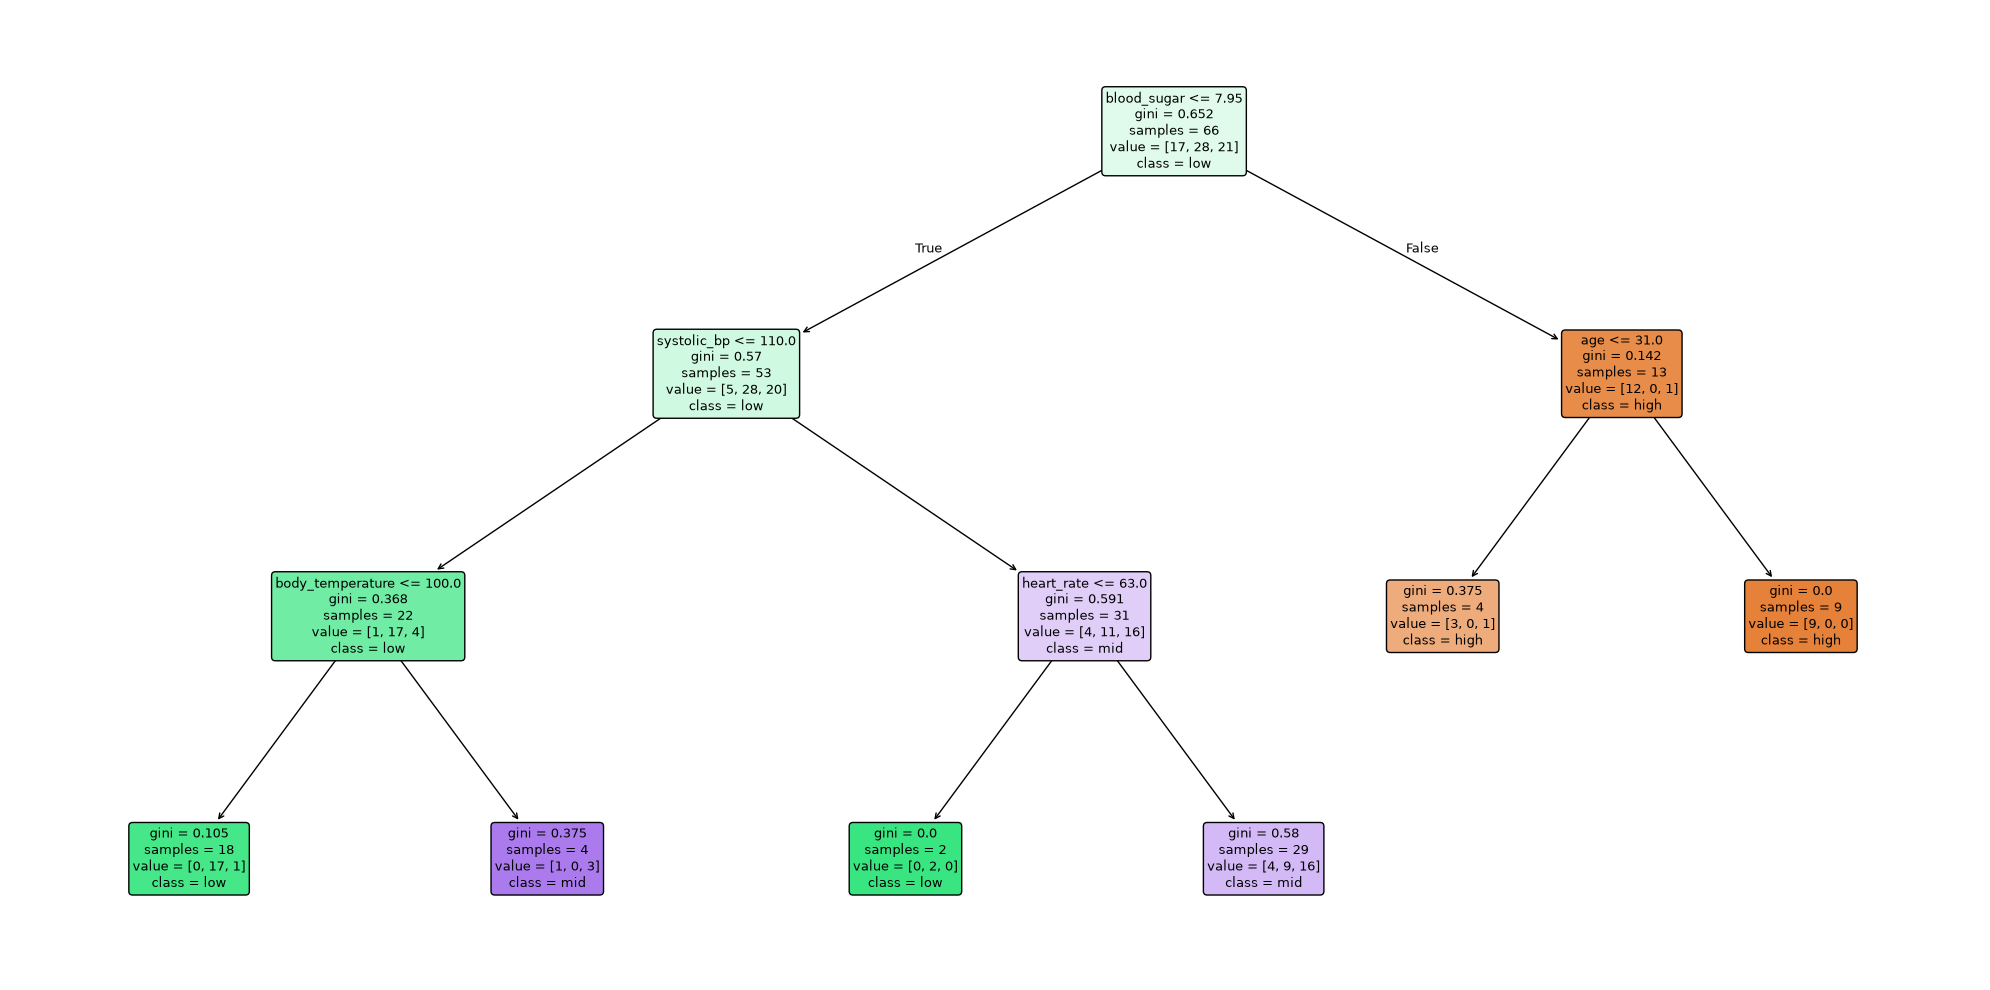

In [21]:
# from sklearn.tree import export_text
# tree_rules = export_text(
#     decision_tree,
#     feature_names=t_numerical_columns,
# )
# print(tree_rules)

plot_decision_tree(
    decision_tree,
    numerical_columns=t_numerical_columns,
)
